In [ ]:
import os, glob, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
import os
SYNTHETIC_DATA = False
DAPT_BASE = r"C:\Users\ADMIN\Desktop\Dữ Liệu\dapt_2020\csv"
DAPT_CSV_PATHS = {
    1: [f'{DAPT_BASE}/enp0s3-monday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-monday-pvt.pcap_Flow.csv'],
    2: [f'{DAPT_BASE}/enp0s3-public-tuesday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-tuesday.pcap_Flow.csv'],
    3: [f'{DAPT_BASE}/enp0s3-public-wednesday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-wednesday.pcap_Flow.csv'],
    4: [f'{DAPT_BASE}/enp0s3-public-thursday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-thursday.pcap_Flow.csv'],
    5: [f'{DAPT_BASE}/enp0s3-tcpdump-friday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-tcpdump-pvt-friday.pcap_Flow.csv'],
}
DAPT_LABEL_COL = 'Label'
# ============================================================
# MAPPING NHÃN → APT PHASE (0..4)
# ============================================================
ATTACK_TO_PHASE = {
    # Phase 0 — Benign
    'Benign': 0, 'benign': 0, 'BENIGN': 0, 'Normal': 0, 'normal': 0,

    # Phase 1 — Reconnaissance
    'Network Scan': 1, 'NetworkScan': 1, 'network scan': 1,
    'Web vulnerability Scan': 1, 'Web Vulnerability Scan': 1,
    'WebVulnerabilityScan': 1, 'Port Scan': 1, 'PortScan': 1,
    'Reconnaissance': 1,

    # Phase 2 — Foothold
    'SQL injection': 2, 'SQL Injection': 2, 'SQLInjection': 2,
    'Backdoor': 2, 'backdoor': 2,
    'Malware Download': 2, 'MalwareDownload': 2,
    'Command Injection': 2, 'CommandInjection': 2,
    'CSRF': 2, 'csrf': 2,
    'Account brute force': 2, 'AccountBruteForce': 2, 'BruteForce': 2,
    'Foothold': 2,
    'Establish Foothold': 2,  # <-- THÊM ĐỂ FIX LỖI 8604 DÒNG BỊ LỌT

    # Phase 3 — Lateral Movement
    'DoS': 3, 'dos': 3, 'DenialOfService': 3,
    'Privilege escalation': 3, 'PrivilegeEscalation': 3,
    'Lateral Movement': 3, 'LateralMovement': 3,

    # Phase 4 — Exfiltration
    'Data Exfiltration': 4, 'DataExfiltration': 4,
    'Exfiltration': 4, 'exfiltration': 4,
}
APT_PHASE_NAMES = [
    'Benign', 'Reconnaissance', 'Foothold', 'Lateral Movement', 'Exfiltration'
]

N_APT_PHASES = len(APT_PHASE_NAMES)
N_PCA       = 20
N_BINS      = 32
BATCH_SIZE  = 1024
NUM_WORKERS = 4
EPOCHS      = 35
LR          = 1e-3
D_MODEL     = 256
N_HEADS     = 8
N_PERSIST   = 4
SWA_WINDOW  = 16
LMM_LAYERS  = 6          
LMM_DROPOUT = 0.1        
HEAD_DROPOUT = 0.1       
OUTLIER_TH  = 3.0
PRE_BATCH   = 50_000

N_SYNTHETIC = 5000
N_FEATURES  = 40


if not SYNTHETIC_DATA:
    for day, paths in DAPT_CSV_PATHS.items():
        for path in paths:
            status = 'Ok' if os.path.exists(path) else 'Not ok'
            print(f'  Day {day}: {os.path.basename(path)} {status}')

  Day 1: enp0s3-monday.pcap_Flow.csv Ok
  Day 1: enp0s3-monday-pvt.pcap_Flow.csv Ok
  Day 2: enp0s3-public-tuesday.pcap_Flow.csv Ok
  Day 2: enp0s3-pvt-tuesday.pcap_Flow.csv Ok
  Day 3: enp0s3-public-wednesday.pcap_Flow.csv Ok
  Day 3: enp0s3-pvt-wednesday.pcap_Flow.csv Ok
  Day 4: enp0s3-public-thursday.pcap_Flow.csv Ok
  Day 4: enp0s3-pvt-thursday.pcap_Flow.csv Ok
  Day 5: enp0s3-tcpdump-friday.pcap_Flow.csv Ok
  Day 5: enp0s3-tcpdump-pvt-friday.pcap_Flow.csv Ok


In [ ]:
import os
def generate_synthetic_dapt(n_per_phase=1000, n_features=40, seed=42):
    np.random.seed(seed)
    dfs = []
    configs = [
        (0.3, 0.1, []),
        (0.5, 0.3, [0, 1, 2]),
        (0.6, 0.4, [5, 6, 7]),
        (0.7, 0.3, [10, 11]),
        (0.9, 0.5, [15, 16]),
    ]
    for phase_id, (mu, sigma, skew) in enumerate(configs):
        data = np.abs(np.random.randn(n_per_phase, n_features) * sigma + mu)
        for f in skew:
            data[:, f] += np.random.exponential(2.0, n_per_phase)
        df_p = pd.DataFrame(data, columns=[f'f{i}' for i in range(n_features)])
        df_p['APT_Phase'] = phase_id
        dfs.append(df_p)
    return pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)


def load_real_dapt(csv_paths, attack_to_phase, label_col_hint='Stage'):
    """Load DAPT 2020 từ Kaggle (sowmyamyneni/dapt2020) có xử lý header tự động."""
    # Bước 1: Thu thập tất cả các file tồn tại
    all_files = []
    for day, paths in csv_paths.items():
        if not isinstance(paths, list):
            paths = [paths]
        for path in paths:
            if os.path.exists(path):
                all_files.append((day, path))
            else:
                print(f'  [Day {day}] ⚠️ Không tìm thấy, bỏ qua: {path}')

    if not all_files:
        raise FileNotFoundError(f'Không tìm thấy bất kỳ file CSV nào tại: {DAPT_BASE}')

    # Bước 2: Tìm file có header để lấy bộ cột chuẩn
    standard_cols = None
    for day, path in all_files:
        with open(path, 'r', errors='ignore') as f:
            first_line = f.readline()
        # Check xem dòng đầu có chứa các từ khóa tiêu biểu của header không
        has_header = any(h in first_line.lower() for h in ["flow id", "flow_id", "src ip", "src_ip", "protocol", "timestamp"])
        if has_header:
            df_temp = pd.read_csv(path, nrows=5)
            standard_cols = list(df_temp.columns)
            print(f'  -> Lấy bộ cột chuẩn từ file có header: {os.path.basename(path)} ({len(standard_cols)} cột)')
            break

    if standard_cols is None:
        raise ValueError("Không tìm thấy file nào có header để lấy danh sách cột chuẩn!")

    # Bước 3: Load tất cả các file (cả có header và không header)
    dfs = []
    for day, path in all_files:
        with open(path, 'r', errors='ignore') as f:
            first_line = f.readline()
        has_header = any(h in first_line.lower() for h in ["flow id", "flow_id", "src ip", "src_ip", "protocol", "timestamp"])

        print(f'Loading Day {day}: {os.path.basename(path)} (Has Header: {has_header}) ...')
        try:
            if has_header:
                df_d = pd.read_csv(path, low_memory=False)
                # Đảm bảo giữ đúng số lượng và thứ tự cột chuẩn
                df_d = df_d.reindex(columns=standard_cols)
            else:
                # File không có header -> dùng standard_cols
                df_d = pd.read_csv(path, header=None, names=standard_cols, low_memory=False)
            
            df_d['Day'] = day
            dfs.append(df_d)
        except Exception as e:
            print(f'  ❌ Lỗi khi đọc file {os.path.basename(path)}: {e}')

    if not dfs:
        raise ValueError("Không load được dataframe nào.")

    df = pd.concat(dfs, ignore_index=True)
    print(f'Concat shape before dedup: {df.shape}')
    df = df.drop_duplicates()
    df = df.reset_index(drop=True)
    print(f'Concat shape after  dedup: {df.shape}')

    # Bước 4: Xác định cột nhãn (Stage hoặc Activity)
    label_col = None
    search_cols = []
    if label_col_hint:
        search_cols.append(label_col_hint)
    search_cols.extend(['Stage', 'stage', 'Activity', 'activity', 'Label', 'label', 'Attack', 'attack', 'Class', 'Category'])
    
    for c in search_cols:
        if c in df.columns:
            label_col = c
            break

    if label_col is None:
        raise ValueError(f'Không tìm thấy cột nhãn. Cột hiện có: {list(df.columns)}')
    print(f'Cột nhãn được chọn: "{label_col}"')

    # Hiển thị nhãn thực tế
    print('\nNhãn thực tế trong cột nhãn:')
    for lbl in sorted(df[label_col].dropna().unique()):
        print(f'  "{lbl}": {(df[label_col]==lbl).sum():,}')

    # Map nhãn → Phase
    # Map nhãn → Phase
    df['APT_Phase'] = df[label_col].map(attack_to_phase)
    unmapped_mask = df['APT_Phase'].isna()
    if unmapped_mask.any():
        unmapped_labels = df.loc[unmapped_mask, label_col].unique()
        raise ValueError(f'CRITICAL ERROR: Dữ liệu chứa các nhãn chưa được mapping: {unmapped_labels}')
    df['APT_Phase'] = df['APT_Phase'].astype(int)

    print('\nPhase Distribution:')
    for i, name in enumerate(APT_PHASE_NAMES):
        cnt = (df['APT_Phase']==i).sum()
        print(f'  Phase {i} ({name:<22}): {cnt:>10,} ({cnt/len(df)*100:5.1f}%)')
    
    return df, label_col


# -------- LOAD --------
if SYNTHETIC_DATA:
    print('🔬 Synthetic Mode')
    df = generate_synthetic_dapt(N_SYNTHETIC // N_APT_PHASES, N_FEATURES)
    feature_cols = [c for c in df.columns if c != 'APT_Phase']
else:
    df, _lc = load_real_dapt(DAPT_CSV_PATHS, ATTACK_TO_PHASE, DAPT_LABEL_COL)
    
    # Bổ sung các biến thể tên của Source Port và Destination Port vào tập drop
    drop = {'APT_Phase', 'Day', _lc, 'Label', 'label', 'Attack', 'attack', 'Class', 'Category', 
            'Src Port', 'Dst Port', 'Source Port', 'Destination Port', 'Src_Port', 'Dst_Port'}
    
    const_cols = set(df.std(numeric_only=True).pipe(lambda s: s[s==0]).index)
    feature_cols = [c for c in df.columns
                    if c not in drop | const_cols
                    and pd.api.types.is_numeric_dtype(df[c])]
    print(f'Feature cols: {len(feature_cols)}')

X_raw = df[feature_cols].values.astype(np.float32)
y_raw = df['APT_Phase'].values.astype(np.int64)
print(f'\nX={X_raw.shape} | y={y_raw.shape} | Classes={N_APT_PHASES}')

  -> Lấy bộ cột chuẩn từ file có header: enp0s3-monday.pcap_Flow.csv (85 cột)
Loading Day 1: enp0s3-monday.pcap_Flow.csv (Has Header: True) ...
Loading Day 1: enp0s3-monday-pvt.pcap_Flow.csv (Has Header: True) ...
Loading Day 2: enp0s3-public-tuesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 2: enp0s3-pvt-tuesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 3: enp0s3-public-wednesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 3: enp0s3-pvt-wednesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 4: enp0s3-public-thursday.pcap_Flow.csv (Has Header: True) ...
Loading Day 4: enp0s3-pvt-thursday.pcap_Flow.csv (Has Header: False) ...
Loading Day 5: enp0s3-tcpdump-friday.pcap_Flow.csv (Has Header: True) ...
Loading Day 5: enp0s3-tcpdump-pvt-friday.pcap_Flow.csv (Has Header: True) ...
Concat shape before dedup: (86691, 86)
Concat shape after  dedup: (86691, 86)
Cột nhãn được chọn: "Stage"

Nhãn thực tế trong cột nhãn:
  "BENIGN": 19,454
  "Benign": 44,258
  "Data Exfiltrati

In [ ]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_raw, y_raw, test_size=0.3, stratify=y_raw, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=2/3, stratify=y_tmp, random_state=SEED)
print(f'Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}')
del X_raw, X_tmp, y_tmp; gc.collect()

Train: (60683, 65) | Val: (8669, 65) | Test: (17339, 65)


20

In [ ]:
nc = min(N_PCA, X_tr.shape[1])
pca = PCA(n_components=nc, random_state=SEED)
X_tr  = pca.fit_transform(X_tr)
X_val = pca.transform(X_val)
X_te  = pca.transform(X_te)
print(
    f'PCA: {nc} components |'
    f' variance={pca.explained_variance_ratio_.sum() * 100:.4f}%'
)

sc = StandardScaler()
X_tr  = sc.fit_transform(X_tr)
X_val = sc.transform(X_val)
X_te  = sc.transform(X_te)

kbd = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
tok_tr  = kbd.fit_transform(X_tr).astype(np.int64)
tok_val = kbd.transform(X_val).astype(np.int64)
tok_te  = kbd.transform(X_te).astype(np.int64)

vocab = [int(max(tok_tr[:,i].max(), tok_val[:,i].max(), tok_te[:,i].max())) + 2
         for i in range(tok_tr.shape[1])]
SEQ_LEN = tok_tr.shape[1]

PCA: 20 components | variance=99.9839%


In [ ]:
class TokenDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).long()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

kw = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
train_loader = DataLoader(TokenDS(tok_tr,  y_tr),  BATCH_SIZE, shuffle=True,  drop_last=True,  **kw)
val_loader   = DataLoader(TokenDS(tok_val, y_val), BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(TokenDS(tok_te,  y_te),  BATCH_SIZE, shuffle=False, **kw)

In [ ]:
ROPE_BASE = 1000.0   

def build_rope_cache(seq_len, inv_freq, device):
    t = torch.arange(seq_len, device=device).float()
    angles = torch.outer(t, inv_freq.to(device))          
    cos = angles.cos().repeat_interleave(2, dim=-1)
    sin = angles.sin().repeat_interleave(2, dim=-1)
    return cos, sin

def apply_rope(x, cos, sin):
    cos = cos.unsqueeze(0).unsqueeze(2)   
    sin = sin.unsqueeze(0).unsqueeze(2)   
    x1 = x[..., 0::2]; x2 = x[..., 1::2]
    x_rot = torch.stack((-x2, x1), dim=-1).flatten(-2)
    return x * cos + x_rot * sin

class Adaptive_Weighting_Attention(nn.Module):
    def __init__(self, d_model, n_heads, d_head, R):
        super().__init__()
        assert R >= 1 and n_heads >= 1 and d_head >= 1
        self.R, self.h, self.dh = R, n_heads, d_head
        self.A = nn.Linear(d_model, R * n_heads, bias=False)
        self.B = nn.Linear(d_model, R * d_head,  bias=False)
        nn.init.xavier_uniform_(self.A.weight)
        nn.init.xavier_uniform_(self.B.weight)

        self.alpha = nn.Parameter(torch.ones(R, n_heads))

    def forward(self, x):                       
        B, L, _ = x.shape
        a = self.A(x).view(B, L, self.R, self.h)    
        b = self.B(x).view(B, L, self.R, self.dh)   

        a = a * self.alpha.view(1, 1, self.R, self.h)

        out = torch.einsum('blrh,blrd->blhd', a, b) / float(self.R)
        return out                              

class FeatureEmbedding(nn.Module):
    def __init__(self, vocab_sizes, d):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(v, d) for v in vocab_sizes])
        self.pos  = nn.Embedding(len(vocab_sizes), d)
        self.norm = nn.LayerNorm(d)

    def forward(self, x):
        B, L = x.shape
        h = torch.stack([self.embs[i](x[:,i]) for i in range(L)], dim=1)
        p = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        return self.norm(h + self.pos(p))

class NeuralLongTermMemory(nn.Module):
    def __init__(self, d, n_heads=8, lmm_r_q=2, lmm_r_k=2, lmm_r_v=2,
                 num_blocks=4, dropout=0.15):
        super().__init__()
        assert d % n_heads == 0
        self.h  = n_heads
        self.dh = d // n_heads

        self.tpa_q = Adaptive_Weighting_Attention(d, n_heads, self.dh, lmm_r_q)
        self.tpa_k = Adaptive_Weighting_Attention(d, n_heads, self.dh, lmm_r_k)
        self.tpa_v = Adaptive_Weighting_Attention(d, n_heads, self.dh, lmm_r_v)

        half = self.dh // 2
        inv_freq = 1.0 / (ROPE_BASE ** (torch.arange(0, half * 2, 2).float() / (half * 2)))
        self.register_buffer('inv_freq', inv_freq)

        hidden = d * 4 // 3
        self.M_blocks = nn.ModuleList([
            nn.ModuleDict({
                'norm': nn.LayerNorm(d),
                'fc1':  nn.Linear(d, hidden),
                'act':  nn.GELU(),
                'drop': nn.Dropout(dropout),
                'fc2':  nn.Linear(hidden, d),
            }) for _ in range(num_blocks)
        ])
        self.M_norm = nn.LayerNorm(d)

        self.alpha = nn.Linear(d, 1)
        self.eta   = nn.Linear(d, 1)
        self.theta = nn.Linear(d, 1)

        self.out_proj = nn.Linear(d, d)
        self.norm     = nn.LayerNorm(d)

    def _M(self, x):
        for b in self.M_blocks:
            h = b['norm'](x)
            h = b['fc2'](b['drop'](b['act'](b['fc1'](h))))
            x = x + h
        return self.M_norm(x)

    def forward(self, h):
        B, L, D = h.shape

        q = self.tpa_q(h)
        k = self.tpa_k(h)
        v = self.tpa_v(h)

        cos, sin = build_rope_cache(L, self.inv_freq, h.device)   
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

        q_flat = q.reshape(B, L, D)
        k_flat = k.reshape(B, L, D)
        v_flat = v.reshape(B, L, D)

        a = torch.sigmoid(self.alpha(h))
        e = torch.sigmoid(self.eta(h))
        t = torch.sigmoid(self.theta(h)) * 0.1

        Mt = torch.zeros(B, D, device=h.device)
        St = torch.zeros(B, D, device=h.device)
        outs = []
        for i in range(L):
            v_hat = self._M(k_flat[:, i]) + Mt
            St    = e[:, i] * St - t[:, i] * 2 * (v_hat - v_flat[:, i])
            Mt    = (1 - a[:, i]) * Mt + St
            outs.append(self.out_proj(self._M(q_flat[:, i]) + Mt))
        return self.norm(torch.stack(outs, dim=1))


class SlidingWindowAttention(nn.Module):
    def __init__(self, d, n_heads, window=16,
                 swa_r_q=2, swa_r_k=2, swa_r_v=2):
        super().__init__()
        assert d % n_heads == 0
        self.h      = n_heads
        self.dh     = d // n_heads
        self.window = window
        self.scale  = self.dh ** -0.5

        self.tpa_q = Adaptive_Weighting_Attention(d, n_heads, self.dh, swa_r_q)
        self.tpa_k = Adaptive_Weighting_Attention(d, n_heads, self.dh, swa_r_k)
        self.tpa_v = Adaptive_Weighting_Attention(d, n_heads, self.dh, swa_r_v)

        half = self.dh // 2
        inv_freq = 1.0 / (ROPE_BASE ** (torch.arange(0, half * 2, 2).float() / (half * 2)))
        self.register_buffer('inv_freq', inv_freq)

        self.out_proj = nn.Linear(d, d)
        self.norm     = nn.LayerNorm(d)   

    def forward(self, x):                 
        B, L, D = x.shape

        h = self.norm(x)

        q = self.tpa_q(h)
        k = self.tpa_k(h)
        v = self.tpa_v(h)

        cos, sin = build_rope_cache(L, self.inv_freq, x.device)
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

        q = q.permute(0, 2, 1, 3)
        k = k.permute(0, 2, 1, 3)
        v = v.permute(0, 2, 1, 3)

        idx  = torch.arange(L, device=x.device)
        diff = idx.unsqueeze(0) - idx.unsqueeze(1)
        mask = (diff > 0) | (diff < -(self.window - 1))
        mask = mask.unsqueeze(0).unsqueeze(0)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.masked_fill(mask, float('-inf'))
        attn = F.softmax(attn, dim=-1)

        out = attn @ v                                   
        out = out.permute(0, 2, 1, 3).reshape(B, L, D)  
        return x + self.out_proj(out)


class Titan(nn.Module):
    def __init__(self, vocab_sizes, n_classes,
                 d=256, n_heads=8, n_persist=4, swa_window=16,
                 lmm_blocks=4, lmm_dropout=0.15, head_dropout=0.2,
                 r_q=2, r_k=2, r_v=2):
        super().__init__()
        self.embed  = FeatureEmbedding(vocab_sizes, d)
        self.P      = nn.Parameter(torch.randn(1, n_persist, d) * 0.02)

        self.swa = SlidingWindowAttention(d, n_heads, swa_window,
                                          swa_r_q=r_q, swa_r_k=r_k, swa_r_v=r_v)
        self.lmm = NeuralLongTermMemory(d, n_heads,
                                         lmm_r_q=r_q, lmm_r_k=r_k, lmm_r_v=r_v,
                                         num_blocks=lmm_blocks, dropout=lmm_dropout)

        self.merge     = nn.Linear(d * 2, d)
        self.gate      = nn.Linear(d, d)
        self.gate_norm = nn.LayerNorm(d)

        self.head = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d * 2),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(d * 2, d),
            nn.GELU(),
            nn.Dropout(head_dropout / 2),
            nn.Linear(d, n_classes)
        )
        self.np = n_persist

    def forward(self, x):
        B  = x.size(0)
        h  = self.embed(x)
        xt = torch.cat([self.P.expand(B, -1, -1), h], dim=1)

        y_swa = self.swa(xt)
        y_lmm = self.lmm(xt)

        out = self.merge(torch.cat([y_swa, y_lmm], dim=-1))
        out = self.gate_norm(out * torch.sigmoid(self.gate(xt)))
        out = out[:, self.np:].mean(dim=1)
        return self.head(out)

TPA_R_Q = 2
TPA_R_K = 2
TPA_R_V = 2

model = Titan(vocab, N_APT_PHASES,
                 d=D_MODEL, n_heads=N_HEADS, n_persist=N_PERSIST,
                 swa_window=SWA_WINDOW,
                 lmm_blocks=LMM_LAYERS, lmm_dropout=LMM_DROPOUT,
                 head_dropout=HEAD_DROPOUT,
                 r_q=TPA_R_Q, r_k=TPA_R_K, r_v=TPA_R_V).to(DEVICE)

total = sum(p.numel() for p in model.parameters())



In [ ]:
import copy
from sklearn.utils.class_weight import compute_class_weight

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        p_t = torch.exp(-ce_loss)
        focal_term = (1 - p_t) ** self.gamma
        loss = focal_term * ce_loss
        if self.weight is not None:
            sample_weights = self.weight[targets]
            loss = loss * sample_weights
        return loss.mean()

# === TÍNH CLASS WEIGHTS CHUẨN ===
classes_present = np.unique(y_tr)
computed_w = compute_class_weight(class_weight='balanced', classes=classes_present, y=y_tr)
weights = np.ones(N_APT_PHASES, dtype=np.float32)
for c, w in zip(classes_present, computed_w):
    weights[c] = np.clip(w, 0.1, 20.0)
weights = weights / weights.mean()

class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
criterion = FocalLoss(weight=class_weights_tensor, gamma=2.0)

def run_eval(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.cpu().numpy())
    t, p = np.array(all_true), np.array(all_preds)
    return {
        'acc':  accuracy_score(t, p),
        'f1':   f1_score(t, p, average='weighted', zero_division=0),
        'prec': precision_score(t, p, average='weighted', zero_division=0),
        'rec':  recall_score(t, p, average='weighted', zero_division=0),
        'true': t,
        'pred': p,
    }

# Optimizer với weight_decay 1e-2 giúp chống overfit tốt hơn
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = []
best_f1_macro = -np.inf                   # Điểm tốt nhất = F1 macro
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
best_epoch = 0
best_metrics = {}

patience = 5
min_delta = 1e-4
patience_counter = 0

for ep in range(1, EPOCHS + 1):
    # ---------------- TRAIN ----------------
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    scheduler.step()
    avg_train_loss = np.mean(train_losses)

    # ---------------- VALIDATION ----------------
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_losses.append(criterion(model(xb), yb).item())
    avg_val_loss = np.mean(val_losses)

    # ---------------- METRICS ----------------
    m = run_eval(model, val_loader)

    f1_macro    = f1_score(m['true'], m['pred'], average='macro',    zero_division=0)
    f1_weighted = f1_score(m['true'], m['pred'], average='weighted', zero_division=0)

    # Điểm chọn model = F1 macro
    score = f1_macro

    # ---------------- LOGGING ----------------
    history.append({
        'ep': ep,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'acc': m['acc'],
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro,
    })

    print(f'[Epoch {ep}/{EPOCHS}] '
          f'Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | '
          f'Acc: {m["acc"]:.4f} | F1-W: {f1_weighted:.4f} | '
          f'F1-M: {f1_macro:.4f} ')

    # ---------------- EARLY STOPPING ----------------
    if score > best_f1_macro + min_delta:
        best_f1_macro = score
        best_val_loss = avg_val_loss
        best_epoch = ep
        best_metrics = {
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'acc': m['acc'],
            'val_loss': avg_val_loss,
        }
        best_model_wts = copy.deepcopy(model.state_dict())

        torch.save({
            'epoch': ep,
            'model_state': best_model_wts,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'val_loss': avg_val_loss,
        }, 'best_model.pth')

        patience_counter = 0
        print(f'    NEW BEST @ epoch {ep} | F1-M={f1_macro:.4f} '
              f'(F1-W={f1_weighted:.4f}, ValLoss={avg_val_loss:.4f})')
    else:
        patience_counter += 1
        print(f'    No improvement  | '
              f'best F1-M={best_f1_macro:.4f} @ epoch {best_epoch}')

        if patience_counter >= patience:
            print(f'\n Early stopping tại epoch {ep}')
            print(f' Best F1-M: {best_f1_macro:.4f} @ epoch {best_epoch}')
            print(f'   Best metrics: {best_metrics}')
            break

# ---------------- RESTORE BEST MODEL ----------------
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state'])
print(f'\n✅ Đã load checkpoint tốt nhất (epoch {checkpoint["epoch"]}, '
      f'F1-M={checkpoint["f1_macro"]:.4f})')

RuntimeError: DataLoader worker (pid(s) 63840, 41628, 36020, 48536) exited unexpectedly


===== TEST METRICS  =====
Accuracy        : 0.8285
F1  (weighted)  : 0.8535
F1  (macro)     : 0.5672
Precision (w)   : 0.9046
Recall    (w)   : 0.8285

                  precision    recall  f1-score   support

          Benign       0.99      0.82      0.90     12743
  Reconnaissance       0.64      0.83      0.72      2382
        Foothold       0.83      0.86      0.84      1721
Lateral Movement       0.23      0.90      0.37       490
    Exfiltration       0.00      0.00      0.00         3

        accuracy                           0.83     17339
       macro avg       0.54      0.68      0.57     17339
    weighted avg       0.90      0.83      0.85     17339



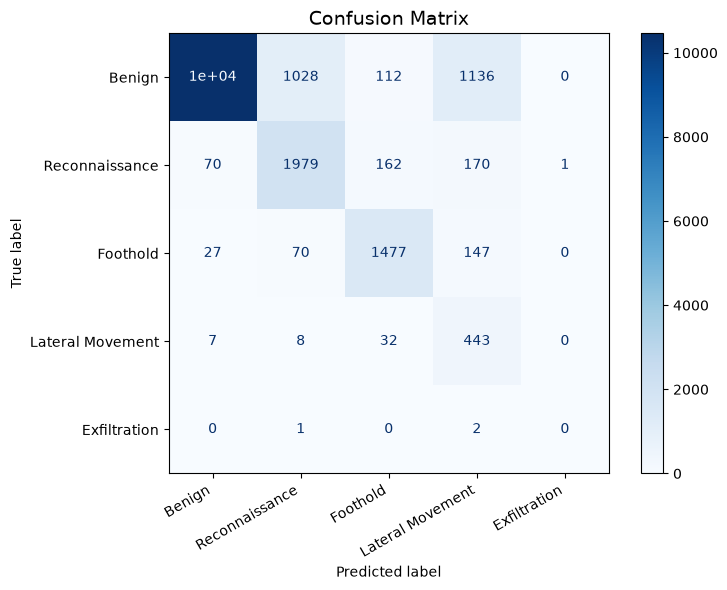

In [ ]:
m = run_eval(model, test_loader)
print('\n===== TEST METRICS  =====')
print(f'Accuracy        : {m["acc"]:.4f}')
print(f'F1  (weighted)  : {m["f1"]:.4f}')
print(f'F1  (macro)     : {f1_score(m["true"], m["pred"], average="macro", zero_division=0):.4f}')
print(f'Precision (w)   : {m["prec"]:.4f}')
print(f'Recall    (w)   : {m["rec"]:.4f}')
print()
print(classification_report(m['true'], m['pred'],
                             target_names=APT_PHASE_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix(m['true'], m['pred']),
    display_labels=APT_PHASE_NAMES
).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('dapt2020_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
!pip install thop -q


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  COMPUTE COST & MEMORY USAGE — STID-dapt
  Forward FLOPs (G)        :       0.2248
  Training FLOPs (T)       :     450.1487
  VRAM inference (GB)      :       0.0905
  VRAM train (GB)          :       3.7636


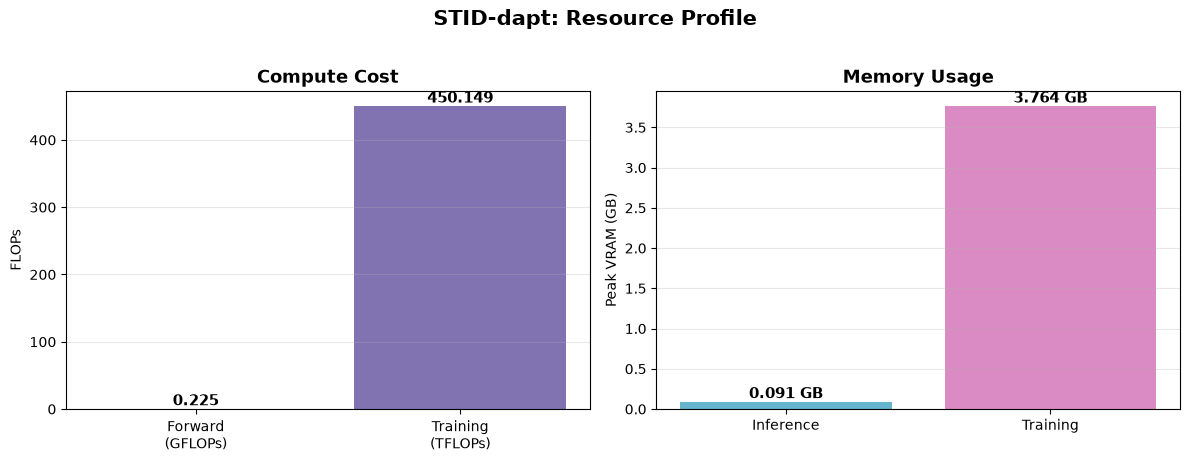


💾 Đã lưu: stid_profiling.png, stid_profiling.json


In [ ]:
# ============================================================
# VISUALIZE COMPUTE COST & MEMORY USAGE — STID-dapt
# ============================================================
import time, json
from thop import profile
import matplotlib.pyplot as plt
import numpy as np
import torch

# ---------- 1. PARAMS ----------
total_params = sum(p.numel() for p in model.parameters())

# ---------- 2. FLOPs (forward) ----------
model.eval()
dummy = torch.randint(0, N_BINS, (1, SEQ_LEN)).to(DEVICE)

try:
    macs, _ = profile(model, inputs=(dummy,), verbose=False)
    flops_forward = macs * 2
except Exception as e:
    print(f"⚠️ thop failed: {e}, dùng fallback 6*N*L")
    flops_forward = 2 * total_params * SEQ_LEN

# ---------- 3. VRAM ----------
if DEVICE.type == 'cuda':
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad():
        _ = model(dummy)
    vram_infer = torch.cuda.max_memory_allocated() / 1e9

    torch.cuda.reset_peak_memory_stats()
    model.train()
    _xb = torch.randint(0, N_BINS, (BATCH_SIZE, SEQ_LEN)).to(DEVICE)
    _yb = torch.randint(0, N_APT_PHASES, (BATCH_SIZE,)).to(DEVICE)
    _opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    _loss = criterion(model(_xb), _yb)
    _loss.backward()
    _opt.step()
    vram_train = torch.cuda.max_memory_allocated() / 1e9
    del _xb, _yb, _loss, _opt
    torch.cuda.empty_cache()
else:
    vram_infer = 0.0
    vram_train = 0.0

# ---------- 4. TỔNG FLOPs TRAINING ----------
n_train = len(train_loader.dataset)
n_epochs_actual = checkpoint['epoch']
flops_train_total = flops_forward * 3 * n_train * n_epochs_actual

# ---------- 5. IN KẾT QUẢ ----------
results = {
    "Forward FLOPs (G)":   flops_forward / 1e9,
    "Training FLOPs (T)":  flops_train_total / 1e12,
    "VRAM inference (GB)": vram_infer,
    "VRAM train (GB)":     vram_train,
}

print("\n" + "="*55)
print("  COMPUTE COST & MEMORY USAGE — STID-dapt")
print("="*55)
for k, v in results.items():
    print(f"  {k:<25}: {v:>12.4f}")
print("="*55)

# ---------- 6. VISUALIZE ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 6.1 Compute Cost
ax = axes[0]
labels = ['Forward\n(GFLOPs)', 'Training\n(TFLOPs)']
vals = [flops_forward/1e9, flops_train_total/1e12]
bars = ax.bar(labels, vals, color=['#C44E52', '#8172B2'])
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('FLOPs')
ax.set_title('Compute Cost', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 6.2 Memory Usage
ax = axes[1]
labels = ['Inference', 'Training']
vals = [vram_infer, vram_train]
bars = ax.bar(labels, vals, color=['#64B5CD', '#DA8BC3'])
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.3f} GB',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Peak VRAM (GB)')
ax.set_title('Memory Usage', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('STID-dapt: Resource Profile', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('stid_profiling.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------- 7. LƯU JSON ----------
with open('stid_profiling.json', 'w') as f:
    json.dump({k: float(v) for k, v in results.items()}, f, indent=2)
print("\n💾 Đã lưu: stid_profiling.png, stid_profiling.json")